# 03 · Model Experiments

We compare three models on the same **temporal** split (train on older loans,
test on the most recent — the honest analogue of scoring future applicants):

| Model | Why it's here |
|---|---|
| Logistic Regression | Transparent, regulator-friendly baseline |
| Random Forest | Non-linear reference |
| XGBoost | Primary challenger |

All runs are logged to **MLflow**. This notebook reuses the exact training code
in `src/loan_default/train.py` so the notebook and the production pipeline can
never disagree.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, confusion_matrix

sys.path.insert(0, str(Path.cwd().parent / "src"))
from loan_default.config import load_config
from loan_default.dataset import FEATURE_COLUMNS, build_model_ready
from loan_default.train import candidate_models, evaluate, temporal_split

cfg = load_config()

## 1. Data and temporal split

In [2]:
df = build_model_ready(cfg)
train_df, test_df = temporal_split(df, cfg)
X_train, y_train = train_df[FEATURE_COLUMNS], train_df["default"].to_numpy()
X_test, y_test = test_df[FEATURE_COLUMNS], test_df["default"].to_numpy()
pos_weight = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))
print(f"train {len(train_df):,} (default {y_train.mean():.1%}) | "
      f"test {len(test_df):,} (default {y_test.mean():.1%})")

train 4,250 (default 15.9%) | test 1,063 (default 19.0%)


## 2. Fit and compare

`candidate_models` automatically loads the Optuna-tuned XGBoost params from
`artifacts/best_params.json` if `uv run tune` has been run (see the tuning
section at the end); otherwise it uses conservative defaults.

In [3]:
models = candidate_models(cfg, pos_weight)
fitted, rows, probas = {}, [], {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    p = pipe.predict_proba(X_test)[:, 1]
    fitted[name], probas[name] = pipe, p
    rows.append({"model": name, **evaluate(y_test, p, cfg["model"]["decision_threshold"])})

results = pd.DataFrame(rows).set_index("model").round(3)
results

Using tuned params for: logistic_regression, random_forest, xgboost


/Users/deepaklodha/Documents/machine_learning/Interview Prep/finance_house_prod/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/deepaklodha/Documents/machine_learning/Interview Prep/finance_house_prod/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,roc_auc,pr_auc,ks,brier,precision,recall,f1
model,,,,,,,
logistic_regression,0.832,0.583,0.522,0.185,0.389,0.777,0.518
random_forest,0.823,0.533,0.511,0.157,0.435,0.683,0.532
xgboost,0.829,0.572,0.522,0.156,0.427,0.738,0.541


**Metric choice.** We lead with **ROC-AUC** (ranking quality — the brief asks
us to *rank* applicants) and **PR-AUC** (more informative under class
imbalance). **KS** is the classic credit-risk separation statistic; **Brier**
checks probability calibration for later threshold-setting.

## 3. ROC & Precision-Recall curves

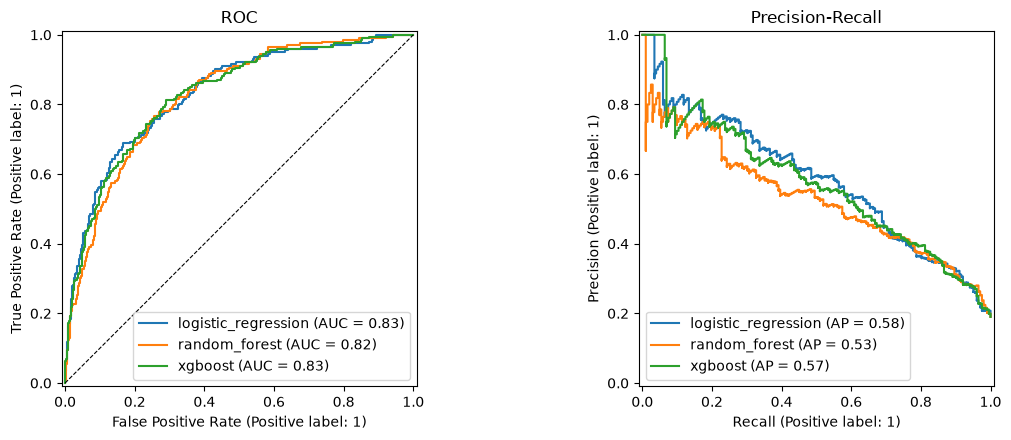

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for name, p in probas.items():
    RocCurveDisplay.from_predictions(y_test, p, name=name, ax=ax[0])
    PrecisionRecallDisplay.from_predictions(y_test, p, name=name, ax=ax[1])
ax[0].set_title("ROC"); ax[1].set_title("Precision-Recall")
ax[0].plot([0, 1], [0, 1], "k--", lw=0.8)
plt.tight_layout(); plt.show()

## 4. Threshold analysis (business trade-off)

The decision threshold is a *business* choice, not a modelling one: it trades
approving bad loans (defaults let through) against declining good ones (lost
revenue). We plot precision/recall vs threshold for the primary model.

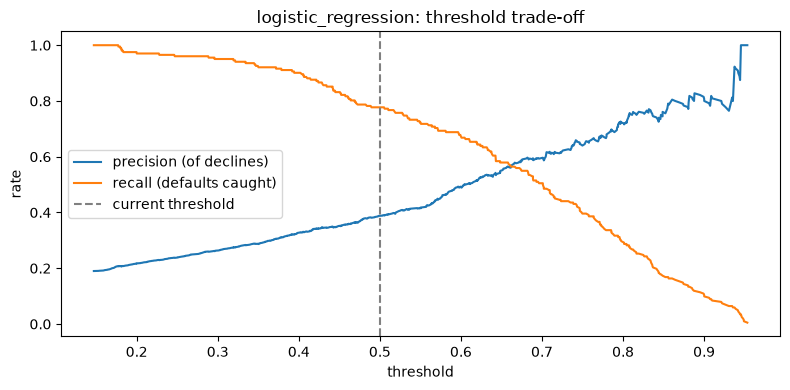

In [5]:
from sklearn.metrics import precision_recall_curve

primary = cfg["model"]["primary"]
prec, rec, thr = precision_recall_curve(y_test, probas[primary])
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thr, prec[:-1], label="precision (of declines)")
ax.plot(thr, rec[:-1], label="recall (defaults caught)")
ax.axvline(cfg["model"]["decision_threshold"], color="grey", ls="--", label="current threshold")
ax.set_xlabel("threshold"); ax.set_ylabel("rate"); ax.legend(); ax.set_title(f"{primary}: threshold trade-off")
plt.tight_layout(); plt.show()

## 5. What drives the primary model?

For a tree model we read gain-based importances; for the linear model we
read the coefficients (log-odds). Either way this should echo the target
analysis in notebook 02 (bureau score, DPD history, affordability ratios).


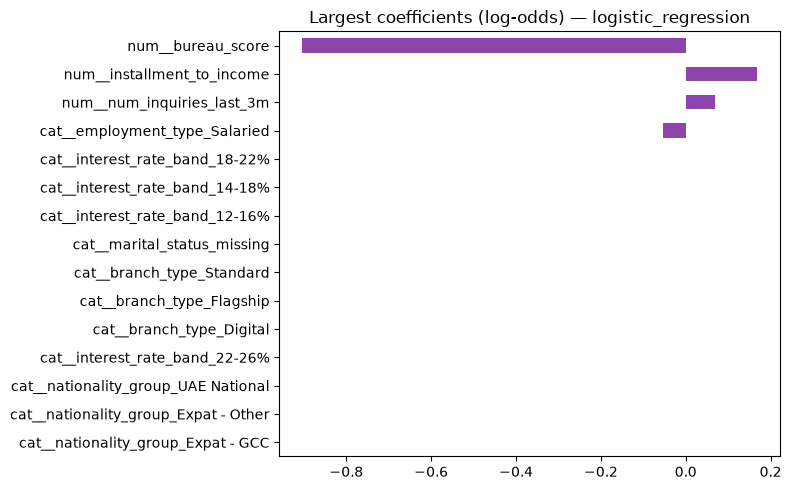

In [6]:
prep = fitted[primary].named_steps["prep"]
clf = fitted[primary].named_steps["clf"]
feat_names = prep.get_feature_names_out()
if hasattr(clf, "feature_importances_"):
    imp, title = pd.Series(clf.feature_importances_, index=feat_names), f"Top gain-based importances — {primary}"
elif hasattr(clf, "coef_"):
    imp, title = pd.Series(clf.coef_[0], index=feat_names), f"Largest coefficients (log-odds) — {primary}"
else:
    imp = None
if imp is not None:
    imp.reindex(imp.abs().sort_values().index).tail(15).plot(kind="barh", figsize=(8, 5), color="#8e44ad")
    plt.title(title); plt.tight_layout(); plt.show()


## 6. Confusion matrix at the operating threshold

In [7]:
pred = (probas[primary] >= cfg["model"]["decision_threshold"]).astype(int)
cm = confusion_matrix(y_test, pred)
print(pd.DataFrame(cm, index=["actual good", "actual bad"],
                   columns=["pred good", "pred bad"]))

             pred good  pred bad
actual good        614       247
actual bad          45       157


## 7. Hyperparameter tuning (Optuna)

XGBoost is tuned with Optuna via `uv run tune`: 40 TPE trials optimising PR-AUC
under **time-aware** cross-validation (`TimeSeriesSplit`) on the training split
only, so the hold-out stays untouched. Tuning lifts XGBoost from ROC-AUC ~0.816
to ~0.829. Best params land in `artifacts/best_params.json` and are consumed by
the next `uv run train`. Rationale is in `docs/DECISION_LOG.md` §9a.

In [8]:
import json
from pathlib import Path

pp = Path.cwd().parent / "artifacts" / "best_params.json"
print("Tuned XGBoost params:\n", json.dumps(json.loads(pp.read_text()), indent=2)
      if pp.exists() else "(run `uv run tune` first)")

Tuned XGBoost params:
 {
  "logistic_regression": {
    "C": 0.007903550181642046,
    "penalty": "l1"
  },
  "random_forest": {
    "n_estimators": 500,
    "max_depth": 17,
    "min_samples_leaf": 12,
    "max_features": "sqrt"
  },
  "xgboost": {
    "n_estimators": 500,
    "max_depth": 4,
    "learning_rate": 0.011492999300221412,
    "subsample": 0.8430179407605753,
    "colsample_bytree": 0.6682096494749166,
    "min_child_weight": 1,
    "gamma": 4.7444276862666666,
    "reg_lambda": 7.2866537374910445,
    "reg_alpha": 1.7123375973163988
  }
}


## 8. MLflow

Running `uv run train` logs every model's params + metrics to MLflow
(`sqlite:///mlflow.db`). Browse and compare runs with:

```bash
uv run mlflow ui --backend-store-uri sqlite:///mlflow.db
```

The model named in `config.model.primary` is saved to `artifacts/model.joblib`
and is what the `/predict` service loads.